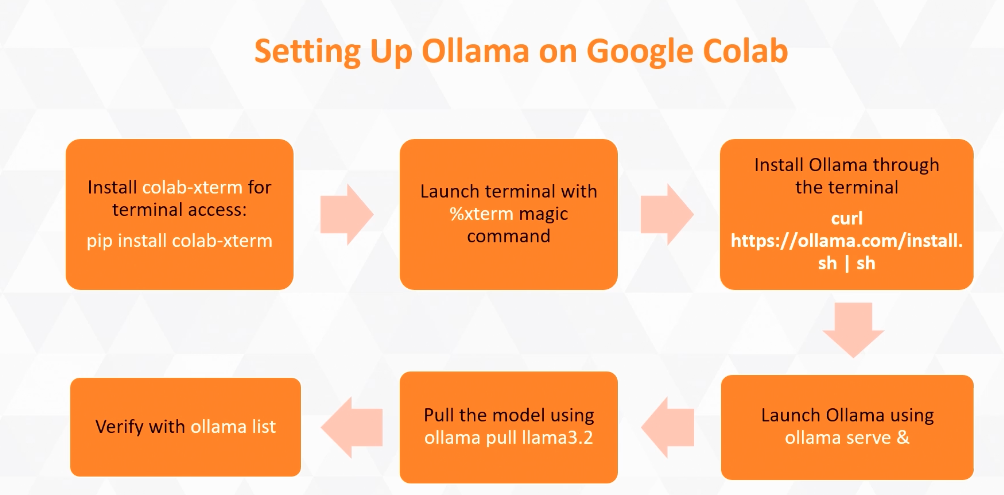

In [1]:
!pip install colab-xterm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.6/115.6 kB 3.9 MB/s eta 0:00:00


In [7]:
!apt-get install -y zstd

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 7 not upgraded.
Need to get 603 kB of archives.
After this operation, 1,695 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 603 kB in 1s (616 kB/s)
Selecting previously unselected package zstd.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...


In [2]:
%load_ext colabxterm

In [ ]:
import subprocess
import os

print("Downloading Ollama binary...")
# Download the Ollama binary directly
subprocess.run(['curl', '-L', 'https://ollama.com/download/ollama-linux-amd64', '-o', 'ollama'], check=True)

# Make the binary executable
subprocess.run(['chmod', '+x', 'ollama'], check=True)

# Move the binary to /usr/local/bin, which is typically in the PATH
# If this fails due to permissions, we'll try /usr/bin or /content/ollama
try:
    subprocess.run(['sudo', 'mv', 'ollama', '/usr/local/bin/'], check=True)
    print("Ollama moved to /usr/local/bin")
except subprocess.CalledProcessError as e:
    print(f"Could not move to /usr/local/bin directly: {e}. Trying /usr/bin...")
    try:
        subprocess.run(['sudo', 'mv', 'ollama', '/usr/bin/'], check=True)
        print("Ollama moved to /usr/bin")
    except subprocess.CalledProcessError as e:
        print(f"Could not move to /usr/bin either: {e}. Moving to /content/ and adding to PATH.")
        subprocess.run(['mv', 'ollama', '/content/'], check=True)
        os.environ['PATH'] += os.pathsep + '/content/'

# Verify Ollama installation
print("Verifying Ollama installation...")
try:
    ollama_version_output = subprocess.run(['ollama', '--version'], capture_output=True, text=True, check=True)
    print(ollama_version_output.stdout)
    print("Ollama installation complete!")
except subprocess.CalledProcessError as e:
    print(f"Failed to verify Ollama: {e}")
    print("Please try running 'ollama --version' in the %xterm terminal after restarting it.")


In [6]:
%xterm

Launching Xterm...

<IPython.core.display.Javascript object>

In [8]:
!ollama list

NAME               ID              SIZE      MODIFIED           
llama3.2:latest    a80c4f17acd5    2.0 GB    About a minute ago    


In [10]:
!pip install langchain_ollama

In [12]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama.llms import OllamaLLM
from IPython.display import display, Markdown
import torch

template = """Question:{question}
Answer: You are a helpful assistant"""

template = ChatPromptTemplate.from_template(template)

#Detect GPU availability using torch
if torch.cuda.is_available():
    device = torch.device("cuda")
    print('GPU detected. Using GPU for inference')
else:
    device = torch.device("cpu")
    print('No GPU detected. Using CPU for inference')

model = OllamaLLM(model="llama3.2", device=device)
chain = template | model
output = chain.invoke({"question": "What is the capital of France?"})
display(Markdown(output))

No GPU detected. Using CPU for inference


The capital of France is Paris.